<h1 style="font-family:Georgia,serif;color:#1a252f;font-size:2em;border-bottom:3px solid #2980b9;padding-bottom:10px;margin-bottom:6px;">
  Notebook 03 &mdash; Construção e Análise dos Grafos de Coocorrência
</h1>
<p style="font-family:Georgia,serif;color:#666;font-size:1.05em;margin-top:4px;margin-bottom:22px;">
  Dissertações de Mestrado em Engenharia Elétrica e de Computação &mdash; Três estratégias de janela de contexto
</p>
<div style="background:#f4f8fb;border-left:4px solid #2980b9;padding:12px 16px;border-radius:3px;font-family:sans-serif;font-size:0.92em;color:#333;line-height:1.65;">
  <strong>Objetivo:</strong> construir três grafos de coocorrência de entidades nomeadas a partir
  dos artefatos do Notebook 02, comparando janelas de contexto por <strong>parágrafo (chunk)</strong>,
  por <strong>sentença</strong> e por <strong>janela de k&nbsp;caracteres</strong>.
  Em seguida, analisar cada grafo com as métricas da disciplina: densidade, grau, componentes
  conectados, coeficiente de clustering e propriedades de small world.
</div>
<br>
<table style="font-family:sans-serif;font-size:0.88em;color:#444;border-collapse:collapse;">
  <tr><td style="padding:3px 20px 3px 0;color:#888;">Entrada</td><td><code>results/02_ner_analysis/02_all_entities_gliner.csv</code> &nbsp;+&nbsp; <code>data/extracted_text/*.json</code></td></tr>
  <tr><td style="padding:3px 20px 3px 0;color:#888;">Saída grafos</td><td><code>graphs/graph_paragraph.graphml</code>, <code>graph_sentence.graphml</code>, <code>graph_kchars.graphml</code></td></tr>
  <tr><td style="padding:3px 20px 3px 0;color:#888;">Saída métricas</td><td><code>results/03_graph_analysis/03_metrics_summary.csv</code></td></tr>
  <tr><td style="padding:3px 20px 3px 0;color:#888;">Biblioteca de grafos</td><td>networkx</td></tr>
</table>

<h2 style="font-family:Georgia,serif;color:#2c3e50;border-bottom:1px solid #dce0e4;padding-bottom:6px;margin-top:30px;">
  1. Configuração
</h2>
<p style="font-family:sans-serif;font-size:0.9em;color:#555;line-height:1.65;max-width:820px;">
  Importações, definição de caminhos, estilo global e constantes do pipeline.
  Todos os diretórios de saída são criados automaticamente caso não existam.
</p>

In [1]:
import re
import json
import warnings
from pathlib import Path
from collections import Counter, defaultdict
from itertools import combinations
from IPython.display import display, HTML

import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import plotly.graph_objects as go

warnings.filterwarnings("ignore")
print("Imports OK.")

Imports OK.


In [2]:
# ── Caminhos do projeto ──────────────────────────────────────────────────────
ROOT         = Path("..")
DIR_TEXT     = ROOT / "data" / "extracted_text"
DIR_ENT      = ROOT / "data" / "entities" / "gliner"
DIR_GRAPHS   = ROOT / "graphs"
DIR_FIGURES  = ROOT / "figures" / "03_graph_analysis"
DIR_RESULTS  = ROOT / "results" / "03_graph_analysis"
DIR_RESULTS_NB02 = ROOT / "results" / "02_ner_analysis"
ENT_CSV      = DIR_RESULTS_NB02 / "02_all_entities_gliner.csv"
DIR_META     = ROOT / "metadados_teses"

for d in [DIR_GRAPHS, DIR_FIGURES, DIR_RESULTS]:
    d.mkdir(parents=True, exist_ok=True)

ENT_FILES  = sorted(DIR_ENT.glob("*.json"))
TEXT_FILES = sorted(DIR_TEXT.glob("*.json"))
TEXT_IDS   = [f.stem for f in TEXT_FILES]

print(f"CSV de entidades limpas: {'sim' if ENT_CSV.exists() else 'nao'}")
print(f"JSONs de entidades    : {len(ENT_FILES)}")
print(f"Arquivos de texto     : {len(TEXT_FILES)}")
print(f"IDs de texto: {TEXT_IDS}")
print()
for label, d in [("results/02_ner_analysis/02_all_entities_gliner.csv", ENT_CSV),
                  ("data/entities/gliner", DIR_ENT),
                  ("data/extracted_text ", DIR_TEXT),
                  ("graphs              ", DIR_GRAPHS),
                  ("figures/03_graph_analysis", DIR_FIGURES),
                  ("results/03_graph_analysis", DIR_RESULTS)]:
    print(f"  {label}  {'✓ ok' if d.exists() else '✗ NAO ENCONTRADO'}")

CSV de entidades limpas: sim
JSONs de entidades    : 13
Arquivos de texto     : 13
IDs de texto: ['01', '03', '05', '09', '11', '12', '13', '14', '15', '16', '17', '18', '19']

  results/02_ner_analysis/02_all_entities_gliner.csv  ✓ ok
  data/entities/gliner  ✓ ok
  data/extracted_text   ✓ ok
  graphs                ✓ ok
  figures/03_graph_analysis  ✓ ok
  results/03_graph_analysis  ✓ ok


In [3]:
# ── Estilo global dos gráficos ───────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":        130,
    "figure.facecolor":  "white",
    "axes.facecolor":    "#f9f9f9",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#e2e2e2",
    "grid.linestyle":    "--",
    "grid.linewidth":    0.6,
    "font.size":         11,
    "axes.titlesize":    12,
    "axes.labelsize":    11,
})

COR_AZUL    = "#2980b9"
COR_LARANJA = "#e67e22"
COR_VERDE   = "#27ae60"
COR_ROXO    = "#8e44ad"
COR_VERMELHO= "#c0392b"
PALETA      = [COR_AZUL, COR_LARANJA, COR_VERDE, COR_ROXO, COR_VERMELHO,
               "#16a085", "#d35400", "#2c3e50"]

# Cores por estratégia (usadas em múltiplos gráficos)
CORES_ESTRATEGIA = {
    "Parágrafo": COR_AZUL,
    "Sentença":  COR_LARANJA,
    "k-chars":   COR_VERDE,
}

print("Estilo aplicado.")

Estilo aplicado.


In [4]:
# ── Constantes do pipeline ───────────────────────────────────────────────────
K_CHARS   = 500   # tamanho da janela em caracteres (estratégia k-chars)
FREQ_MIN  = 3     # frequência mínima de uma entidade para entrar no grafo
WEIGHT_MIN = 1    # peso mínimo de aresta para manter (1 = manter todas)

# ── Mesmo preprocessamento do NB02 ───────────────────────────────────────────
CHUNK_SIZE = 4
REF_RE  = re.compile(
    r'^\s*(referências\s*(bibliográficas)?|references?|bibliography)\s*$',
    re.IGNORECASE)
DOTS_RE = re.compile(r'\.\s*\.\s*\.')
NUM_RE  = re.compile(r'^[\d\s\.\-,]+$')

def preprocess(tese_data: dict) -> list[str]:
    """Reconstrói os chunks de texto exatamente como o NB02 fez."""
    pages = tese_data["pages"]
    cut_at = len(pages)
    for i, page in enumerate(pages):
        first_line = page.strip().split("\n")[0].strip()
        if REF_RE.match(first_line):
            cut_at = i
            break
    clean_lines = []
    for page in pages[:cut_at]:
        for line in page.split("\n"):
            line = line.strip()
            if len(line) < 25:                          continue
            if DOTS_RE.search(line):                    continue
            if NUM_RE.match(line):                      continue
            alpha_ratio = sum(c.isalpha() for c in line) / len(line)
            if alpha_ratio < 0.4:                       continue
            clean_lines.append(line)
    chunks = []
    for i in range(0, len(clean_lines), CHUNK_SIZE):
        text = " ".join(clean_lines[i:i + CHUNK_SIZE])
        text = re.sub(r"(\w)-\s+(\w)", r"\1\2", text)
        text = re.sub(r"\s{2,}", " ", text).strip()
        if len(text) >= 60:
            chunks.append(text)
    return chunks

print(f"K_CHARS={K_CHARS}  |  FREQ_MIN={FREQ_MIN}  |  WEIGHT_MIN={WEIGHT_MIN}")
print("Função preprocess() definida.")

K_CHARS=500  |  FREQ_MIN=3  |  WEIGHT_MIN=1
Função preprocess() definida.


<h2 style="font-family:Georgia,serif;color:#2c3e50;border-bottom:1px solid #dce0e4;padding-bottom:6px;margin-top:30px;">
  2. Carregamento das Entidades
</h2>
<p style="font-family:sans-serif;font-size:0.9em;color:#555;line-height:1.65;max-width:820px;">
  O notebook prefere a tabela consolidada e limpa produzida pelo Notebook 02
  (<code>results/02_ner_analysis/02_all_entities_gliner.csv</code>). Se ela ainda não existir, usa
  os JSONs brutos em <code>data/entities/gliner/</code> como fallback.
</p>

In [5]:
# ── Carrega entidades já limpas do NB02 (ou cai para os JSONs brutos) ───────
if ENT_CSV.exists():
    df = pd.read_csv(ENT_CSV, encoding="utf-8-sig")
    fonte_entidades = f"CSV limpo: {ENT_CSV.name}"
else:
    rows = []
    for f in ENT_FILES:
        with open(f, encoding="utf-8") as fh:
            rows.extend(json.load(fh))
    df = pd.DataFrame(rows)
    fonte_entidades = "JSONs brutos em data/entities/gliner/"

df["tese_id"] = df["tese_id"].astype(str).str.replace(".0", "", regex=False).str.zfill(2)
TESE_IDS = sorted(df["tese_id"].unique().tolist())
ALL_ENTS = {tid: grp.to_dict(orient="records") for tid, grp in df.groupby("tese_id")}

print(f"Fonte das entidades: {fonte_entidades}")
print(f"Total de entidades carregadas: {len(df):,}")
print(f"Colunas disponíveis: {list(df.columns)}")
print(f"IDs com entidades: {TESE_IDS}")
print()
print(df.groupby("label")["text_norm"].count().sort_values(ascending=False).to_string())

Fonte das entidades: CSV limpo: 02_all_entities_gliner.csv
Total de entidades carregadas: 2,458
Colunas disponíveis: ['text', 'text_norm', 'label', 'label_full', 'score', 'chunk_idx', 'tese_id']
IDs com entidades: ['01', '03', '05', '09', '11', '12', '13', '14', '15', '16', '17', '18', '19']

label
HARDWARE       706
ALGORITMO      627
METODO         340
AUTOR          169
LANG           157
INSTITUICAO    128
FRAMEWORK      116
PROTOCOLO      112
EMPRESA        103


In [6]:
# ── Filtro de frequência mínima (mesma regra do NB02) ────────────────────────
freq = df["text_norm"].value_counts()
entities_validas = set(freq[freq >= FREQ_MIN].index)

df_f = df[df["text_norm"].isin(entities_validas)].copy()
print(f"Entidades únicas totais    : {df['text_norm'].nunique():>6,}")
print(f"Entidades com freq ≥ {FREQ_MIN}    : {len(entities_validas):>6,}")
print(f"Linhas após filtro         : {len(df_f):>6,}")

Entidades únicas totais    :    197
Entidades com freq ≥ 3    :    197
Linhas após filtro         :  2,458


In [7]:
# ── Reconstrói CHUNKS a partir dos textos extraídos ─────────────────────────
CHUNKS = {}

for f in TEXT_FILES:
    tid = f.stem
    if tid not in TESE_IDS:
        continue
    with open(f, encoding="utf-8") as fh:
        data = json.load(fh)
    CHUNKS[tid] = preprocess(data)

loaded = sum(len(v) for v in CHUNKS.values())
print(f"Dissertações com chunks reconstruídos: {len(CHUNKS)}")
print(f"Total de chunks: {loaded:,}")
for tid, chunks in CHUNKS.items():
    n_ents = len([e for e in ALL_ENTS.get(tid, []) if e['text_norm'] in entities_validas])
    print(f"  {tid:>3}  {len(chunks):>5} chunks  |  {n_ents:>5} ents filtradas")

Dissertações com chunks reconstruídos: 13
Total de chunks: 3,567
   01    213 chunks  |     67 ents filtradas
   03    365 chunks  |     85 ents filtradas
   05    364 chunks  |     91 ents filtradas
   09    390 chunks  |     87 ents filtradas
   11    261 chunks  |    242 ents filtradas
   12    266 chunks  |    310 ents filtradas
   13    266 chunks  |    310 ents filtradas
   14    251 chunks  |    256 ents filtradas
   15    299 chunks  |    253 ents filtradas
   16    223 chunks  |    220 ents filtradas
   17    276 chunks  |    329 ents filtradas
   18    195 chunks  |    110 ents filtradas
   19    198 chunks  |     98 ents filtradas


<h2 style="font-family:Georgia,serif;color:#2c3e50;border-bottom:1px solid #dce0e4;padding-bottom:6px;margin-top:30px;">
  3. Construção dos Grafos
</h2>
<p style="font-family:sans-serif;font-size:0.9em;color:#555;line-height:1.65;max-width:820px;">
  Cada estratégia define um critério diferente de <strong>coocorrência</strong>:
  duas entidades coocorrem quando aparecem no mesmo contexto.
  Nós representam entidades; arestas representam coocorrência; o peso da aresta
  é a frequência de coocorrência no corpus.
</p>
<table style="font-family:sans-serif;font-size:0.88em;color:#444;border-collapse:collapse;margin-top:8px;">
  <tr style="border-bottom:1px solid #ddd;"><th style="padding:4px 20px 4px 0;text-align:left;">Estratégia</th><th style="padding:4px 20px 4px 0;text-align:left;">Contexto</th><th style="padding:4px 0;text-align:left;">Característica</th></tr>
  <tr><td style="padding:3px 20px 3px 0;"><strong>Parágrafo</strong></td><td style="padding:3px 20px 3px 0;">Mesmo chunk (4 linhas)</td><td>Contexto mais amplo; mais coocorrências</td></tr>
  <tr><td style="padding:3px 20px 3px 0;"><strong>Sentença</strong></td><td style="padding:3px 20px 3px 0;">Mesma sentença</td><td>Contexto restrito; relações mais precisas</td></tr>
  <tr><td style="padding:3px 20px 3px 0;"><strong>k-chars</strong></td><td style="padding:3px 20px 3px 0;">Janela de K=500 chars</td><td>Granularidade controlável pelo parâmetro k</td></tr>
</table>

In [8]:
# ── Funções auxiliares de construção de grafos ───────────────────────────────

def add_cooccurrence(G: nx.Graph, ents_no_contexto: list[str]) -> None:
    """Adiciona (ou incrementa) arestas entre todos os pares de entidades."""
    unique = list(set(ents_no_contexto))
    for u, v in combinations(unique, 2):
        if G.has_edge(u, v):
            G[u][v]["weight"] += 1
        else:
            G.add_edge(u, v, weight=1)


def split_sentences(text: str) -> list[str]:
    """Divide um texto em sentenças com regra mais robusta para OCR/PDF."""
    parts = re.split(r'(?<=[.!?])\s+', text)
    return [p.strip() for p in parts if len(p.strip()) >= 20]


def compile_entity_pattern(entity: str):
    """Compila regex com fronteiras para evitar matches por substring."""
    escaped = re.escape(entity)
    return re.compile(
        rf'(?<![0-9A-Za-zÀ-ÖØ-öø-ÿ]){escaped}(?![0-9A-Za-zÀ-ÖØ-öø-ÿ])',
        re.IGNORECASE
    )


def ents_em_texto(texto: str, ent_set: set[str], entity_patterns: dict[str, re.Pattern]) -> list[str]:
    """Retorna entidades presentes no texto sem casar substrings espúrias."""
    return [e for e in ent_set if entity_patterns[e].search(texto)]


def build_node_attrs(G: nx.Graph, df_ents: pd.DataFrame) -> None:
    """Adiciona atributo 'label' (tipo) a cada nó do grafo."""
    label_map = (
        df_ents.groupby("text_norm")["label"]
        .agg(lambda s: s.mode().iloc[0])
        .to_dict()
    )
    nx.set_node_attributes(G, label_map, name="label")


print("Funções auxiliares definidas.")

Funções auxiliares definidas.


<h3 style="font-family:Georgia,serif;color:#2c3e50;margin-top:24px;">
  3.1 — Grafo por Parágrafo (chunk)
</h3>
<p style="font-family:sans-serif;font-size:0.9em;color:#555;line-height:1.65;max-width:820px;">
  Duas entidades coocorrem quando aparecem no mesmo <strong>chunk de 4 linhas</strong>,
  que corresponde aproximadamente a um parágrafo.
  Este é o contexto mais amplo dos três e tende a gerar o maior número de arestas.
</p>

In [9]:
# ── Grafo por parágrafo (chunk) ──────────────────────────────────────────────
G_para = nx.Graph(name="Parágrafo", strategy="paragraph")

for tid in TESE_IDS:
    ents_doc = [e for e in ALL_ENTS.get(tid, [])
                if e["text_norm"] in entities_validas]
    # Agrupa entidades por chunk_idx
    by_chunk = defaultdict(list)
    for e in ents_doc:
        by_chunk[e["chunk_idx"]].append(e["text_norm"])
    # Coocorrência dentro de cada chunk
    for chunk_ents in by_chunk.values():
        add_cooccurrence(G_para, chunk_ents)

# Remove arestas com peso abaixo do mínimo
edges_to_remove = [(u, v) for u, v, d in G_para.edges(data=True)
                   if d["weight"] < WEIGHT_MIN]
G_para.remove_edges_from(edges_to_remove)

# Remove nós isolados
G_para.remove_nodes_from(list(nx.isolates(G_para)))

build_node_attrs(G_para, df_f)

print(f"Grafo Parágrafo   →  {G_para.number_of_nodes():>5} nós  |  "
      f"{G_para.number_of_edges():>6} arestas  |  "
      f"densidade={nx.density(G_para):.5f}")

Grafo Parágrafo   →    161 nós  |     359 arestas  |  densidade=0.02787


<h3 style="font-family:Georgia,serif;color:#2c3e50;margin-top:24px;">
  3.2 — Grafo por Sentença
</h3>
<p style="font-family:sans-serif;font-size:0.9em;color:#555;line-height:1.65;max-width:820px;">
  O texto de cada chunk é segmentado em sentenças por pontuação.
  Duas entidades coocorrem apenas quando aparecem na <strong>mesma sentença</strong>.
  Contexto mais restrito: espera-se que produza relações mais semanticamente precisas
  e um grafo com menos arestas e maior especificidade.
</p>

In [10]:
# ── Grafo por sentença ───────────────────────────────────────────────────────
G_sent = nx.Graph(name="Sentença", strategy="sentence")

# Conjunto de entidades válidas para busca rápida por texto
ent_set = entities_validas  # set de text_norm
ENTITY_PATTERNS = {e: compile_entity_pattern(e) for e in ent_set}

for tid in TESE_IDS:
    for chunk in CHUNKS.get(tid, []):
        sentences = split_sentences(chunk)
        if not sentences:
            # Se não conseguiu dividir, trata o chunk inteiro como 1 sentença
            sentences = [chunk]
        for sent in sentences:
            found = ents_em_texto(sent, ent_set, ENTITY_PATTERNS)
            add_cooccurrence(G_sent, found)

edges_to_remove = [(u, v) for u, v, d in G_sent.edges(data=True)
                   if d["weight"] < WEIGHT_MIN]
G_sent.remove_edges_from(edges_to_remove)
G_sent.remove_nodes_from(list(nx.isolates(G_sent)))
build_node_attrs(G_sent, df_f)

print(f"Grafo Sentença    →  {G_sent.number_of_nodes():>5} nós  |  "
      f"{G_sent.number_of_edges():>6} arestas  |  "
      f"densidade={nx.density(G_sent):.5f}")

Grafo Sentença    →    179 nós  |     739 arestas  |  densidade=0.04639


<h3 style="font-family:Georgia,serif;color:#2c3e50;margin-top:24px;">
  3.3 — Grafo por Janela de k Caracteres
</h3>
<p style="font-family:sans-serif;font-size:0.9em;color:#555;line-height:1.65;max-width:820px;">
  Para cada chunk, localizam-se todas as ocorrências de cada entidade por posição de caractere.
  Duas entidades coocorrem quando a distância entre qualquer par de ocorrências é menor que
  <code>K_CHARS = 500</code> caracteres.
  A granularidade pode ser ajustada variando <code>K_CHARS</code> na Seção 1.
</p>

In [11]:
# ── Grafo por janela de k caracteres ─────────────────────────────────────────
G_kchars = nx.Graph(name=f"k-chars (k={K_CHARS})", strategy="kchars")

def find_positions(text: str, entity: str, entity_patterns: dict[str, re.Pattern]) -> list[int]:
    """Retorna posições da entidade usando regex com fronteiras."""
    return [m.start() for m in entity_patterns[entity].finditer(text)]


for tid in TESE_IDS:
    for chunk in CHUNKS.get(tid, []):

        # Encontra quais entidades válidas estão presentes neste chunk
        present = ents_em_texto(chunk, ent_set, ENTITY_PATTERNS)
        if len(present) < 2:
            continue

        # Para cada entidade, coleta todas as posições de ocorrência
        pos_map = {}
        for e in present:
            positions = find_positions(chunk, e, ENTITY_PATTERNS)
            if positions:
                pos_map[e] = positions

        # Verifica quais pares estão dentro da janela de K_CHARS
        for e1, e2 in combinations(list(pos_map.keys()), 2):
            pair_found = False
            for p1 in pos_map[e1]:
                for p2 in pos_map[e2]:
                    if abs(p1 - p2) <= K_CHARS:
                        if G_kchars.has_edge(e1, e2):
                            G_kchars[e1][e2]["weight"] += 1
                        else:
                            G_kchars.add_edge(e1, e2, weight=1)
                        pair_found = True
                        break
                if pair_found:
                    break  # conta no máximo uma coocorrência por par em cada chunk

edges_to_remove = [(u, v) for u, v, d in G_kchars.edges(data=True)
                   if d["weight"] < WEIGHT_MIN]
G_kchars.remove_edges_from(edges_to_remove)
G_kchars.remove_nodes_from(list(nx.isolates(G_kchars)))
build_node_attrs(G_kchars, df_f)

print(f"Grafo k-chars     →  {G_kchars.number_of_nodes():>5} nós  |  "
      f"{G_kchars.number_of_edges():>6} arestas  |  "
      f"densidade={nx.density(G_kchars):.5f}")

Grafo k-chars     →    192 nós  |    1184 arestas  |  densidade=0.06457


<h2 style="font-family:Georgia,serif;color:#2c3e50;border-bottom:1px solid #dce0e4;padding-bottom:6px;margin-top:30px;">
  4. Exportação dos Grafos
</h2>
<p style="font-family:sans-serif;font-size:0.9em;color:#555;line-height:1.65;max-width:820px;">
  Os três grafos são salvos no formato <strong>GraphML</strong>, compatível com NetworkX, Gephi e outras ferramentas de análise.
  Um resumo básico é exibido para confirmar a integridade dos arquivos.
</p>

In [12]:
# ── Salva como GraphML ───────────────────────────────────────────────────────
grafos = {
    "Parágrafo": G_para,
    "Sentença":  G_sent,
    "k-chars":   G_kchars,
}
nomes_arquivo = {
    "Parágrafo": "graph_paragraph.graphml",
    "Sentença":  "graph_sentence.graphml",
    "k-chars":   "graph_kchars.graphml",
}

for nome, G in grafos.items():
    path = DIR_GRAPHS / nomes_arquivo[nome]
    nx.write_graphml(G, path)
    n, e = G.number_of_nodes(), G.number_of_edges()
    print(f"  Salvo: {path.name:30s}  ({n} nós, {e} arestas)")

print()
print("Todos os grafos exportados com sucesso.")

  Salvo: graph_paragraph.graphml         (161 nós, 359 arestas)
  Salvo: graph_sentence.graphml          (179 nós, 739 arestas)
  Salvo: graph_kchars.graphml            (192 nós, 1184 arestas)

Todos os grafos exportados com sucesso.


<h2 style="font-family:Georgia,serif;color:#2c3e50;border-bottom:1px solid #dce0e4;padding-bottom:6px;margin-top:30px;">
  5. Métricas Estruturais
</h2>
<p style="font-family:sans-serif;font-size:0.9em;color:#555;line-height:1.65;max-width:820px;">
  Calculamos as principais propriedades estruturais de cada grafo conforme os conceitos
  estudados na disciplina: densidade, grau médio, componentes conectados, diâmetro do
  componente gigante (GCC), distância média e coeficiente de clustering.
</p>

In [13]:
# ── Métricas estruturais ─────────────────────────────────────────────────────

def compute_metrics(G: nx.Graph, name: str) -> dict:
    N = G.number_of_nodes()
    E = G.number_of_edges()

    # Graus
    graus = [d for _, d in G.degree()]
    grau_medio = np.mean(graus) if graus else 0.0

    # Componentes
    comps = list(nx.connected_components(G))
    n_comps = len(comps)
    gcc_nodes = max(comps, key=len) if comps else set()
    GCC = G.subgraph(gcc_nodes).copy()
    gcc_size = len(GCC)

    # Diâmetro e distância média apenas no GCC
    if gcc_size > 1:
        try:
            diam = nx.diameter(GCC)
        except Exception:
            diam = float("nan")
        try:
            dist_media = round(nx.average_shortest_path_length(GCC), 4)
        except Exception:
            dist_media = float("nan")
    else:
        diam, dist_media = float("nan"), float("nan")

    # Clustering
    clust_medio = round(nx.average_clustering(G), 5)

    # Número de triângulos
    triangs = sum(nx.triangles(G).values()) // 3

    return {
        "Estratégia":       name,
        "Nós (N)":          N,
        "Arestas (E)":      E,
        "Densidade":        round(nx.density(G), 6),
        "Grau médio ⟨k⟩":  round(grau_medio, 3),
        "Componentes":      n_comps,
        "GCC (nós)":        gcc_size,
        "Diâmetro GCC":     diam,
        "Dist. média GCC":  dist_media,
        "Clustering médio": clust_medio,
        "Triângulos":       triangs,
    }

print("Calculando métricas (pode demorar para grafos grandes)...")
resultados = [compute_metrics(G, nome) for nome, G in grafos.items()]
df_metrics = pd.DataFrame(resultados).set_index("Estratégia")

# Exibe tabela formatada
df_metrics

Calculando métricas (pode demorar para grafos grandes)...


,Nós (N),Arestas (E),Densidade,Grau médio ⟨k⟩,Componentes,GCC (nós),Diâmetro GCC,Dist. média GCC,Clustering médio,Triângulos
Estratégia,,,,,,,,,,
Parágrafo,161,359,0.027873,4.460,5,151,9,3.1709,0.51530,312
Sentença,179,739,0.046388,8.257,3,174,7,2.6695,0.53437,1317
k-chars,192,1184,0.064572,12.333,2,189,6,2.3726,0.66244,3327


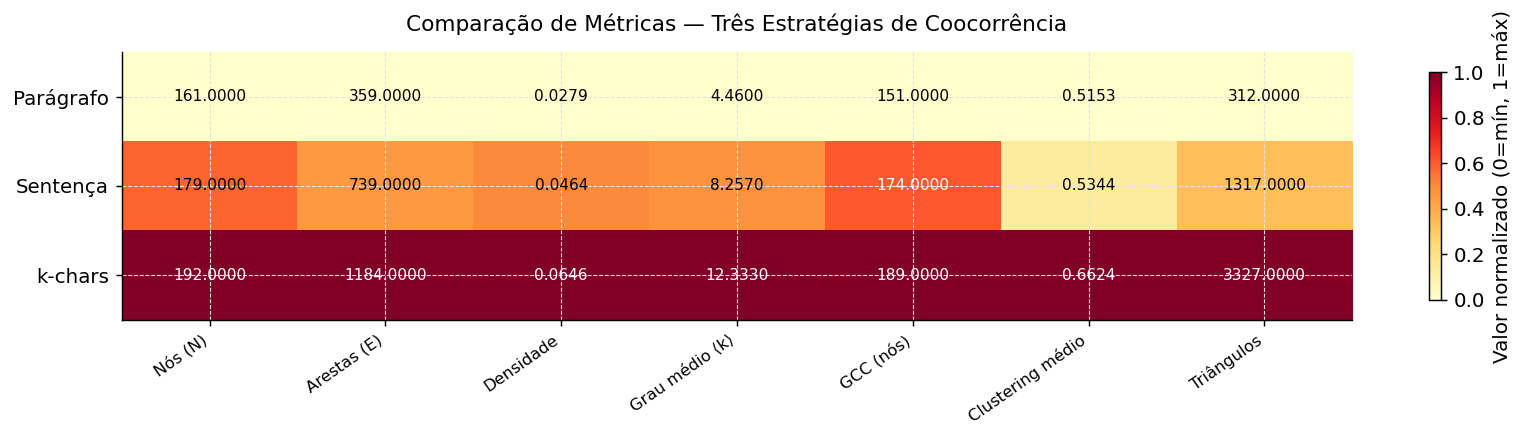

Figura salva: 03_metrics_heatmap.png


In [14]:
# ── Heatmap das métricas (normalizado 0-1 por coluna) ────────────────────────
cols_num = ["Nós (N)", "Arestas (E)", "Densidade", "Grau médio ⟨k⟩",
            "GCC (nós)", "Clustering médio", "Triângulos"]
df_plot = df_metrics[cols_num].copy().astype(float)

# Normaliza 0-1 por coluna (para comparação visual)
df_norm = (df_plot - df_plot.min()) / (df_plot.max() - df_plot.min() + 1e-12)

fig, ax = plt.subplots(figsize=(13, 3.5))
im = ax.imshow(df_norm.values, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(len(cols_num)))
ax.set_xticklabels(cols_num, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(3))
ax.set_yticklabels(df_metrics.index, fontsize=11)

for i in range(3):
    for j, col in enumerate(cols_num):
        val = df_plot.iloc[i][col]
        txt = f"{val:.4f}" if isinstance(val, float) and not np.isnan(val) else str(int(val))
        ax.text(j, i, txt, ha="center", va="center", fontsize=8.5,
                color="black" if df_norm.iloc[i, j] < 0.6 else "white")

plt.colorbar(im, ax=ax, label="Valor normalizado (0=mín, 1=máx)", shrink=0.85)
ax.set_title("Comparação de Métricas — Três Estratégias de Coocorrência",
             fontsize=12, pad=12)
plt.tight_layout()
plt.savefig(DIR_FIGURES / "03_metrics_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salva: 03_metrics_heatmap.png")

In [15]:
# ── Salva métricas como CSV (usado pelo NB04) ────────────────────────────────
out_csv = DIR_RESULTS / "03_metrics_summary.csv"
df_metrics.to_csv(out_csv, encoding="utf-8-sig")
print(f"Métricas salvas: {out_csv}")
print()
print(df_metrics.to_string())

Métricas salvas: ../results/03_graph_analysis/03_metrics_summary.csv

            Nós (N)  Arestas (E)  Densidade  Grau médio ⟨k⟩  Componentes  GCC (nós)  Diâmetro GCC  Dist. média GCC  Clustering médio  Triângulos
Estratégia                                                                                                                                      
Parágrafo       161          359   0.027873           4.460            5        151             9           3.1709           0.51530         312
Sentença        179          739   0.046388           8.257            3        174             7           2.6695           0.53437        1317
k-chars         192         1184   0.064572          12.333            2        189             6           2.3726           0.66244        3327


<h2 style="font-family:Georgia,serif;color:#2c3e50;border-bottom:1px solid #dce0e4;padding-bottom:6px;margin-top:30px;">
  6. Análise de Grau
</h2>
<p style="font-family:sans-serif;font-size:0.9em;color:#555;line-height:1.65;max-width:820px;">
  A <strong>distribuição de grau</strong> P(k) mostra a proporção de nós com cada valor de grau.
  Em redes reais, frequentemente observa-se uma cauda longa (lei de potência),
  indicando poucos hubs muito conectados e muitos nós periféricos.
  O gráfico em escala log-log revela esse padrão.
</p>

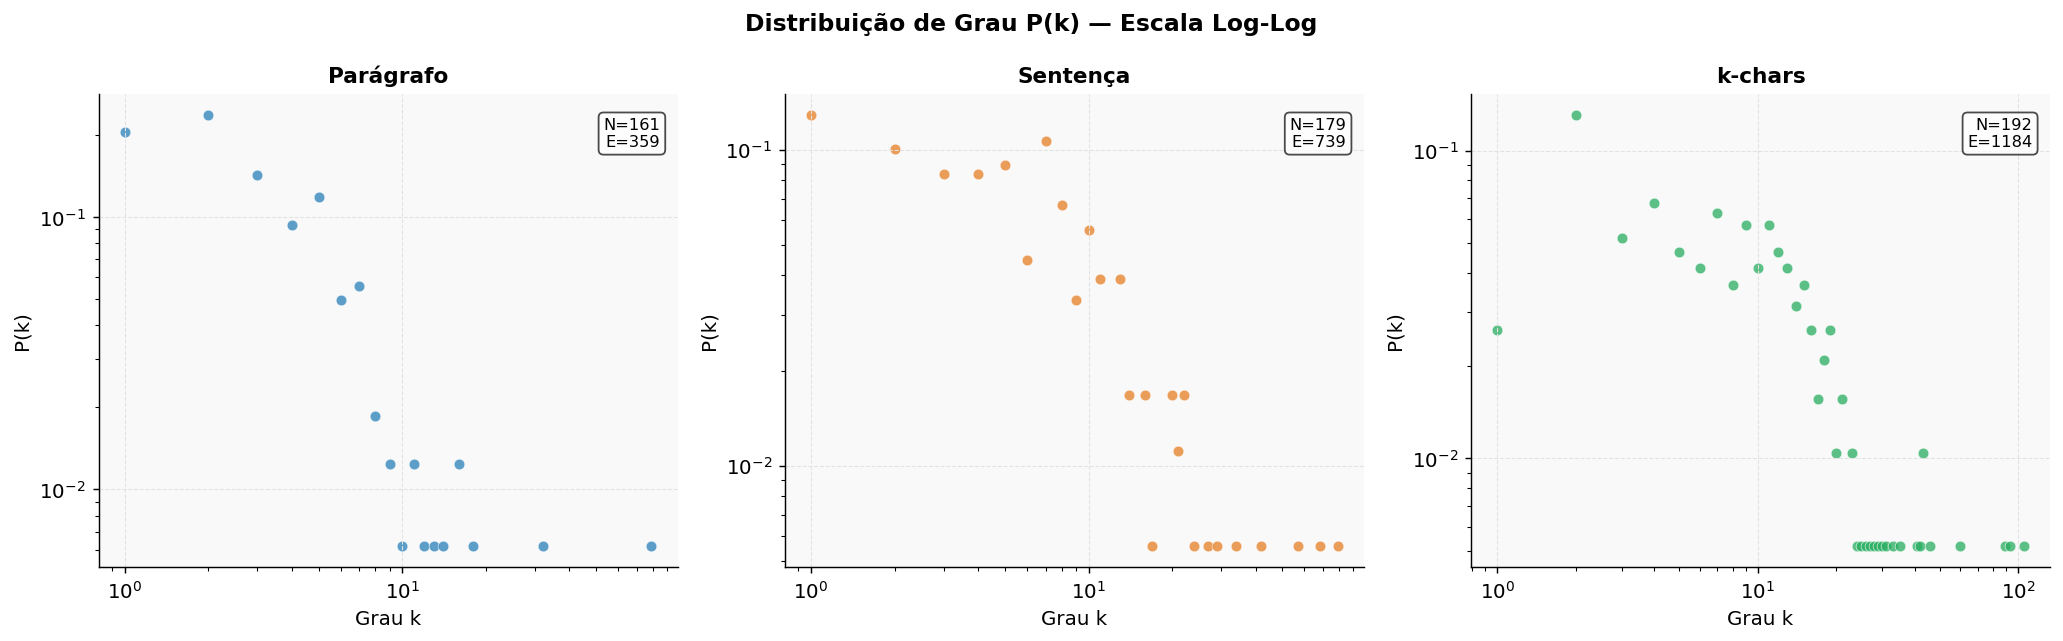

Figura salva: 03_degree_distribution.png


In [16]:
# ── Distribuição de grau — escala log-log ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Distribuição de Grau P(k) — Escala Log-Log", fontsize=13, fontweight="bold")

for ax, (nome, G) in zip(axes, grafos.items()):
    cor = CORES_ESTRATEGIA.get(nome, COR_AZUL)
    degrees = [d for _, d in G.degree()]
    deg_counts = Counter(degrees)
    ks = sorted(deg_counts.keys())
    ps = [deg_counts[k] / G.number_of_nodes() for k in ks]

    ax.scatter(ks, ps, alpha=0.75, s=35, color=cor, edgecolors="white", linewidths=0.4)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(nome, fontweight="bold")
    ax.set_xlabel("Grau k")
    ax.set_ylabel("P(k)")
    ax.text(0.97, 0.95, f"N={G.number_of_nodes()}\nE={G.number_of_edges()}",
            transform=ax.transAxes, ha="right", va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

plt.tight_layout()
plt.savefig(DIR_FIGURES / "03_degree_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salva: 03_degree_distribution.png")

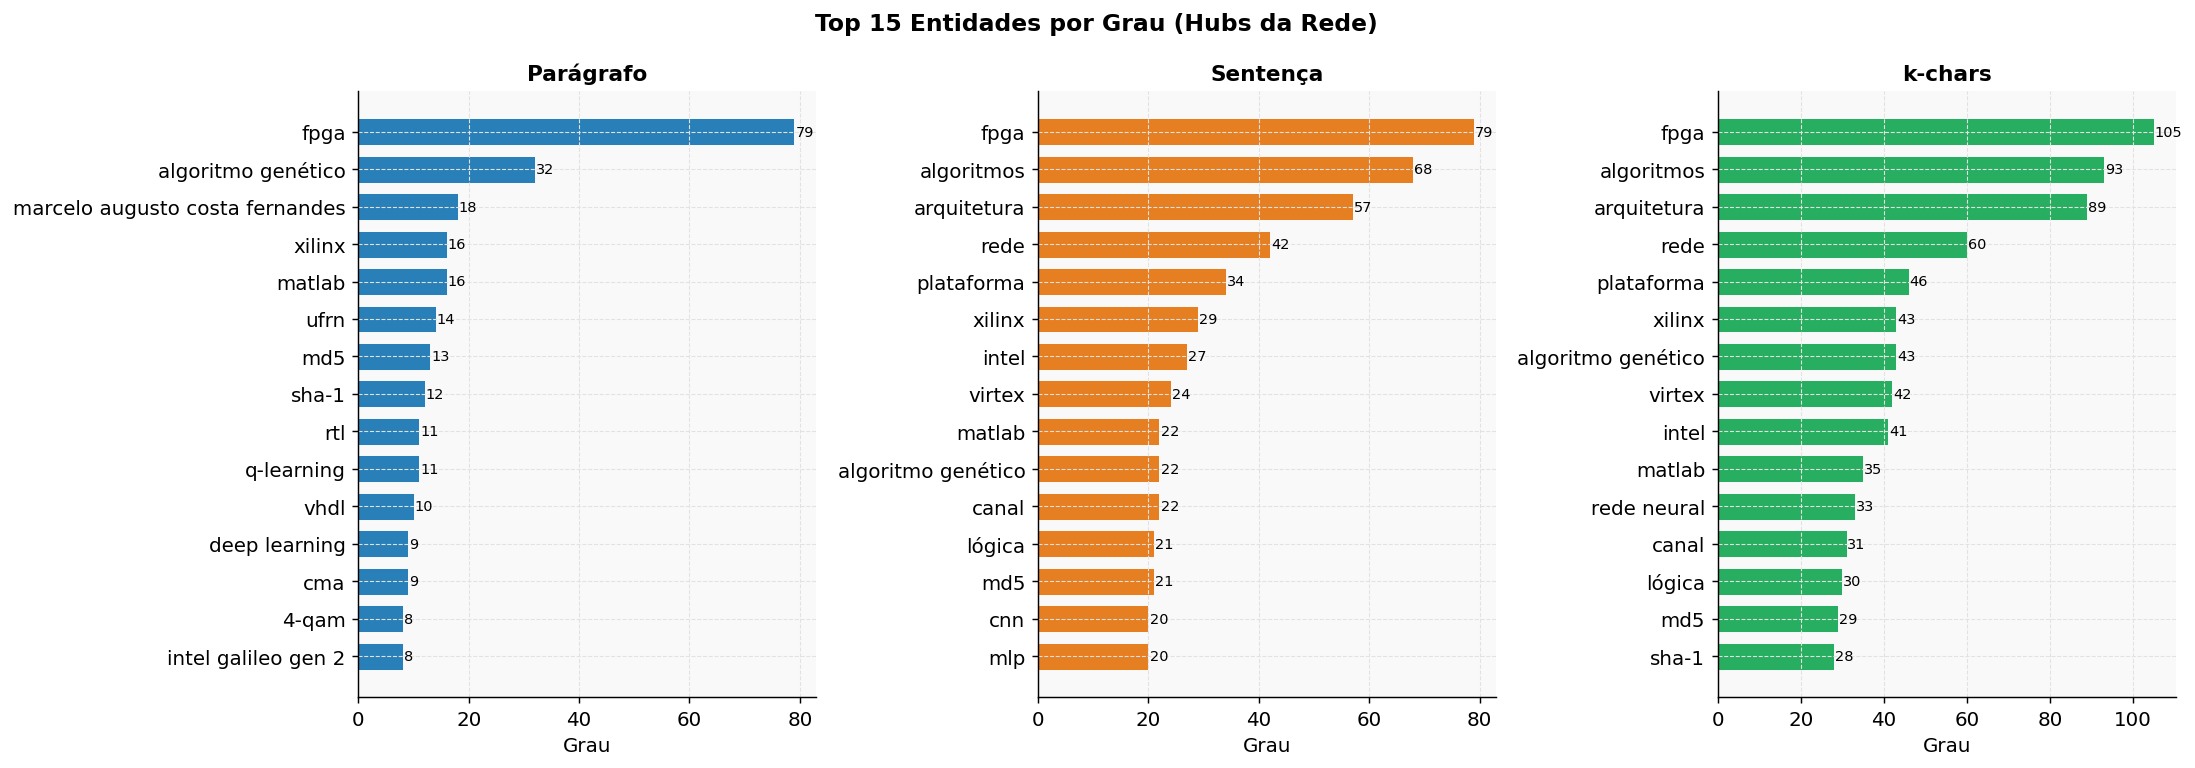



══════════════════════════════════════════════════════
  Top 15 hubs — Parágrafo
══════════════════════════════════════════════════════
  fpga                              grau=  79  [HARDWARE]
  algoritmo genético                grau=  32  [ALGORITMO]
  marcelo augusto costa fernandes   grau=  18  [AUTOR]
  xilinx                            grau=  16  [EMPRESA]
  matlab                            grau=  16  [FRAMEWORK]
  ufrn                              grau=  14  [INSTITUICAO]
  md5                               grau=  13  [ALGORITMO]
  sha-1                             grau=  12  [ALGORITMO]
  rtl                               grau=  11  [LANG]
  q-learning                        grau=  11  [ALGORITMO]
  vhdl                              grau=  10  [LANG]
  deep learning                     grau=   9  [METODO]
  cma                               grau=   9  [ALGORITMO]
  4-qam                             grau=   8  [PROTOCOLO]
  intel galileo gen 2               grau=   8  [HARDWA

In [17]:
# ── Top-15 hubs por grau em cada grafo ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle("Top 15 Entidades por Grau (Hubs da Rede)", fontsize=13, fontweight="bold")

for ax, (nome, G) in zip(axes, grafos.items()):
    cor = CORES_ESTRATEGIA.get(nome, COR_AZUL)
    top15 = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:15]
    nodes, degs = zip(*top15)

    ax.barh(list(nodes)[::-1], list(degs)[::-1], color=cor,
            edgecolor="white", linewidth=0.5, height=0.72)
    ax.set_title(nome, fontweight="bold")
    ax.set_xlabel("Grau")
    for i, (n, d) in enumerate(zip(list(nodes)[::-1], list(degs)[::-1])):
        ax.text(d + 0.2, i, str(d), va="center", fontsize=8)

plt.tight_layout()
plt.savefig(DIR_FIGURES / "03_top_hubs.png", dpi=150, bbox_inches="tight")
plt.show()

# Print tabular
print()
for nome, G in grafos.items():
    top = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:15]
    print(f"\n{'═'*54}")
    print(f"  Top 15 hubs — {nome}")
    print(f"{'═'*54}")
    for node, deg in top:
        label = G.nodes[node].get("label", "?")
        print(f"  {node:32s}  grau={deg:>4}  [{label}]")

<h2 style="font-family:Georgia,serif;color:#2c3e50;border-bottom:1px solid #dce0e4;padding-bottom:6px;margin-top:30px;">
  7. Componentes Conectados
</h2>
<p style="font-family:sans-serif;font-size:0.9em;color:#555;line-height:1.65;max-width:820px;">
  Um <strong>componente conectado</strong> é um subgrafo onde qualquer nó alcança qualquer outro.
  O maior componente — chamado <strong>GCC (Giant Connected Component)</strong> — domina
  a estrutura da rede. Componentes isolados tendem a representar entidades muito específicas
  ou raras que não coocorrem com o núcleo principal.
</p>

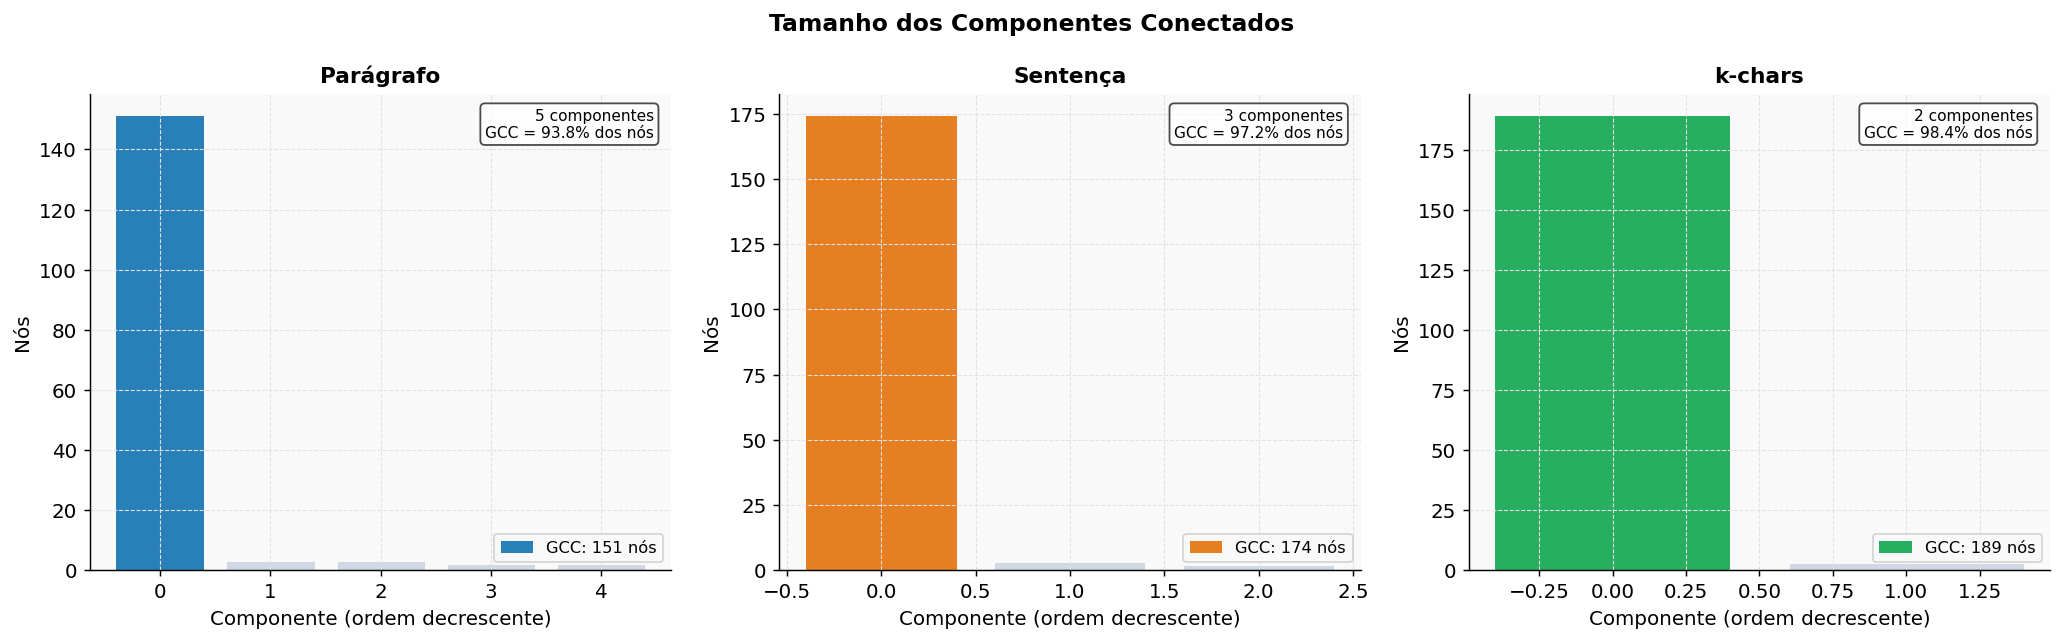

Figura salva: 03_components.png


In [18]:
# ── Distribuição de tamanho dos componentes ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Tamanho dos Componentes Conectados", fontsize=13, fontweight="bold")

for ax, (nome, G) in zip(axes, grafos.items()):
    cor = CORES_ESTRATEGIA.get(nome, COR_AZUL)
    comp_sizes = sorted([len(c) for c in nx.connected_components(G)], reverse=True)
    x = range(len(comp_sizes))

    ax.bar(x, comp_sizes, color="#d0d8e4", edgecolor="white", linewidth=0.4)
    ax.bar(0, comp_sizes[0], color=cor, label=f"GCC: {comp_sizes[0]} nós")

    ax.set_title(nome, fontweight="bold")
    ax.set_xlabel("Componente (ordem decrescente)")
    ax.set_ylabel("Nós")
    ax.legend(fontsize=9)
    ax.text(0.97, 0.97,
            f"{len(comp_sizes)} componentes\n"
            f"GCC = {comp_sizes[0]/G.number_of_nodes()*100:.1f}% dos nós",
            transform=ax.transAxes, ha="right", va="top", fontsize=8.5,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

plt.tight_layout()
plt.savefig(DIR_FIGURES / "03_components.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salva: 03_components.png")

In [19]:
# ── Detalhes do GCC de cada grafo ────────────────────────────────────────────
for nome, G in grafos.items():
    comps  = list(nx.connected_components(G))
    gcc    = max(comps, key=len)
    GCC    = G.subgraph(gcc).copy()
    pct    = len(gcc) / G.number_of_nodes() * 100
    # Top-5 nós do GCC por grau
    top5 = sorted(GCC.degree(), key=lambda x: x[1], reverse=True)[:5]

    print(f"\n{'─'*52}")
    print(f"  GCC — {nome}")
    print(f"{'─'*52}")
    print(f"  Nós no GCC          : {len(gcc):>5}  ({pct:.1f}% da rede)")
    print(f"  Arestas no GCC      : {GCC.number_of_edges():>5}")
    print(f"  Componentes totais  : {len(comps):>5}")
    print(f"  Top-5 hubs no GCC   : {[n for n,_ in top5]}")


────────────────────────────────────────────────────
  GCC — Parágrafo
────────────────────────────────────────────────────
  Nós no GCC          :   151  (93.8% da rede)
  Arestas no GCC      :   351
  Componentes totais  :     5
  Top-5 hubs no GCC   : ['fpga', 'algoritmo genético', 'marcelo augusto costa fernandes', 'xilinx', 'matlab']

────────────────────────────────────────────────────
  GCC — Sentença
────────────────────────────────────────────────────
  Nós no GCC          :   174  (97.2% da rede)
  Arestas no GCC      :   735
  Componentes totais  :     3
  Top-5 hubs no GCC   : ['fpga', 'algoritmos', 'arquitetura', 'rede', 'plataforma']

────────────────────────────────────────────────────
  GCC — k-chars
────────────────────────────────────────────────────
  Nós no GCC          :   189  (98.4% da rede)
  Arestas no GCC      :  1181
  Componentes totais  :     2
  Top-5 hubs no GCC   : ['fpga', 'algoritmos', 'arquitetura', 'rede', 'plataforma']


<h2 style="font-family:Georgia,serif;color:#2c3e50;border-bottom:1px solid #dce0e4;padding-bottom:6px;margin-top:30px;">
  8. Coeficiente de Clustering
</h2>
<p style="font-family:sans-serif;font-size:0.9em;color:#555;line-height:1.65;max-width:820px;">
  O <strong>coeficiente de clustering</strong> C(i) de um nó mede o fechamento triádico:
  que fração dos seus vizinhos também são conectados entre si.
  <br><br>
  $$C(i) = \frac{2\,\tau(i)}{k_i\,(k_i-1)}$$
  <br>
  Onde &tau;(i) é o número de triângulos em que o nó <i>i</i> participa
  e k<sub>i</sub> é o seu grau. Alto clustering indica clusters temáticos coesos.
</p>

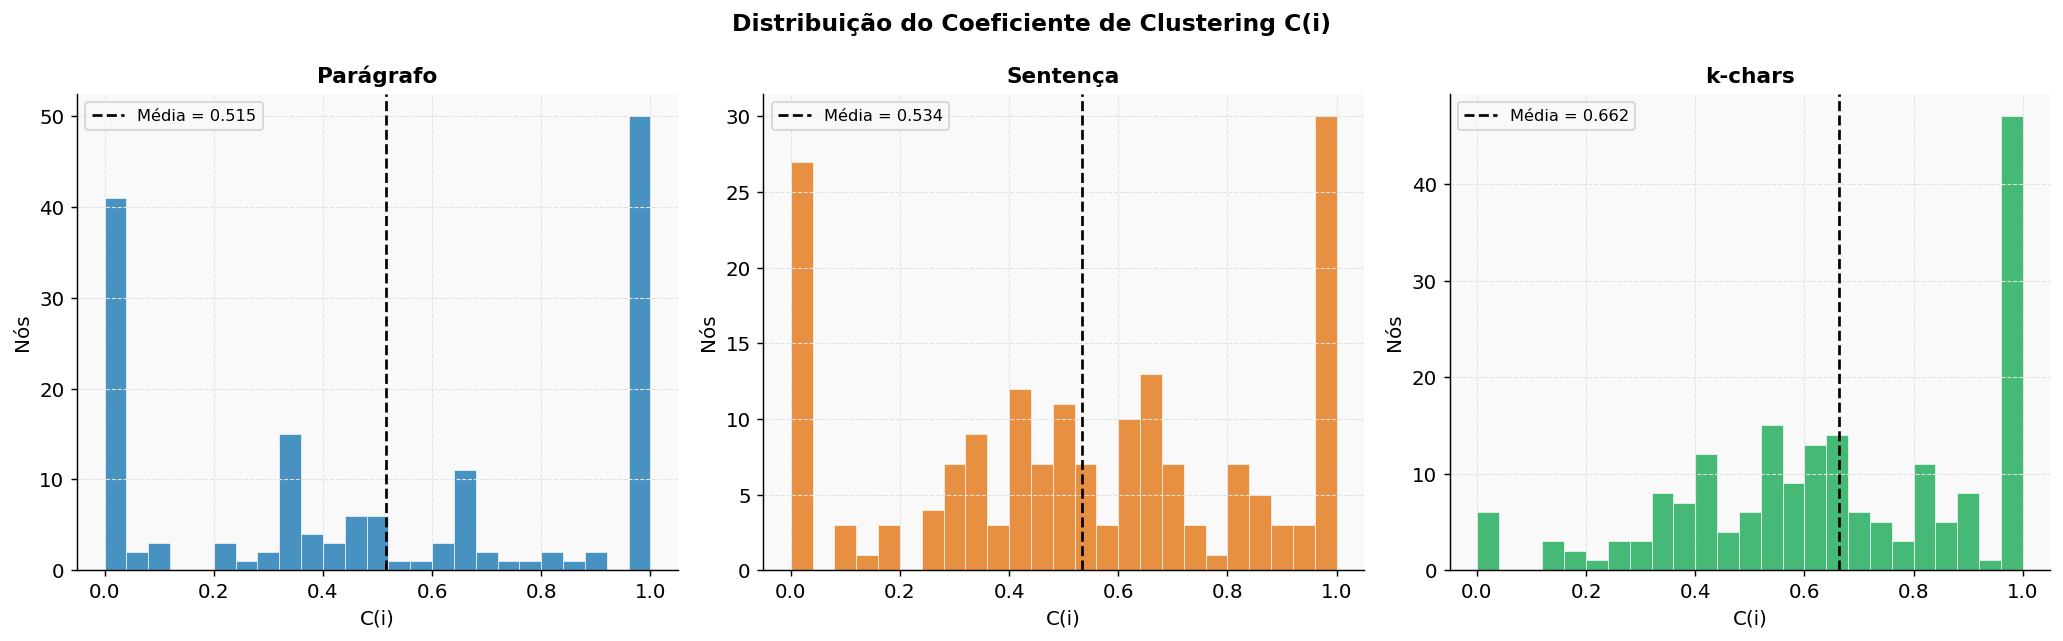

Figura salva: 03_clustering_distribution.png


In [20]:
# ── Histograma de clustering ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Distribuição do Coeficiente de Clustering C(i)", fontsize=13, fontweight="bold")

for ax, (nome, G) in zip(axes, grafos.items()):
    cor = CORES_ESTRATEGIA.get(nome, COR_AZUL)
    clust_vals = list(nx.clustering(G).values())
    media = np.mean(clust_vals)

    ax.hist(clust_vals, bins=25, color=cor, edgecolor="white", linewidth=0.4, alpha=0.85)
    ax.axvline(media, color="black", linestyle="--", linewidth=1.5, label=f"Média = {media:.3f}")
    ax.set_title(nome, fontweight="bold")
    ax.set_xlabel("C(i)")
    ax.set_ylabel("Nós")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(DIR_FIGURES / "03_clustering_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salva: 03_clustering_distribution.png")

In [21]:
# ── Top-10 nós por coeficiente de clustering (grau > 2) ─────────────────────
for nome, G in grafos.items():
    clust = nx.clustering(G)
    filtered = {n: c for n, c in clust.items() if G.degree(n) > 2}
    top10 = sorted(filtered.items(), key=lambda x: x[1], reverse=True)[:10]
    print(f"\n{'═'*56}")
    print(f"  Top 10 clustering — {nome}  (grau > 2)")
    print(f"{'═'*56}")
    for node, c in top10:
        label = G.nodes[node].get("label", "?")
        print(f"  {node:35s}  C={c:.4f}  grau={G.degree(node):>3}  [{label}]")


════════════════════════════════════════════════════════
  Top 10 clustering — Parágrafo  (grau > 2)
════════════════════════════════════════════════════════
  hdl                                  C=1.0000  grau=  4  [LANG]
  programa de pós-graduação em engenharia elétrica  C=1.0000  grau=  5  [INSTITUICAO]
  mengxu & bin                         C=1.0000  grau=  3  [AUTOR]
  oimga                                C=1.0000  grau=  3  [ALGORITMO]
  merabti & massicotte                 C=1.0000  grau=  3  [AUTOR]
  chen & wu                            C=1.0000  grau=  3  [AUTOR]
  matheus f. torquato                  C=1.0000  grau=  5  [AUTOR]
  lucileide m. d. da silva             C=1.0000  grau=  5  [AUTOR]
  método de runge-kutta                C=1.0000  grau=  3  [METODO]
  elcga                                C=1.0000  grau=  5  [METODO]

════════════════════════════════════════════════════════
  Top 10 clustering — Sentença  (grau > 2)
══════════════════════════════════════════════

<h2 style="font-family:Georgia,serif;color:#2c3e50;border-bottom:1px solid #dce0e4;padding-bottom:6px;margin-top:30px;">
  9. Visualização dos Grafos
</h2>
<p style="font-family:sans-serif;font-size:0.9em;color:#555;line-height:1.65;max-width:820px;">
  Visualização do GCC de cada grafo com layout Fruchterman-Reingold (spring).
  O <strong>tamanho de cada nó</strong> é proporcional ao seu grau.
  A <strong>cor</strong> representa o tipo semântico da entidade.
  Cada grafo é exibido separadamente em <strong>3D</strong>, usando layout do
  <code>networkx</code> e renderização interativa com <code>plotly</code>, o que permite
  rotacionar, aproximar e inspecionar os nós diretamente no notebook.
</p>

HTML interativo salvo: ../figures/03_graph_analysis/03_paragrafo_plotly_3d.html


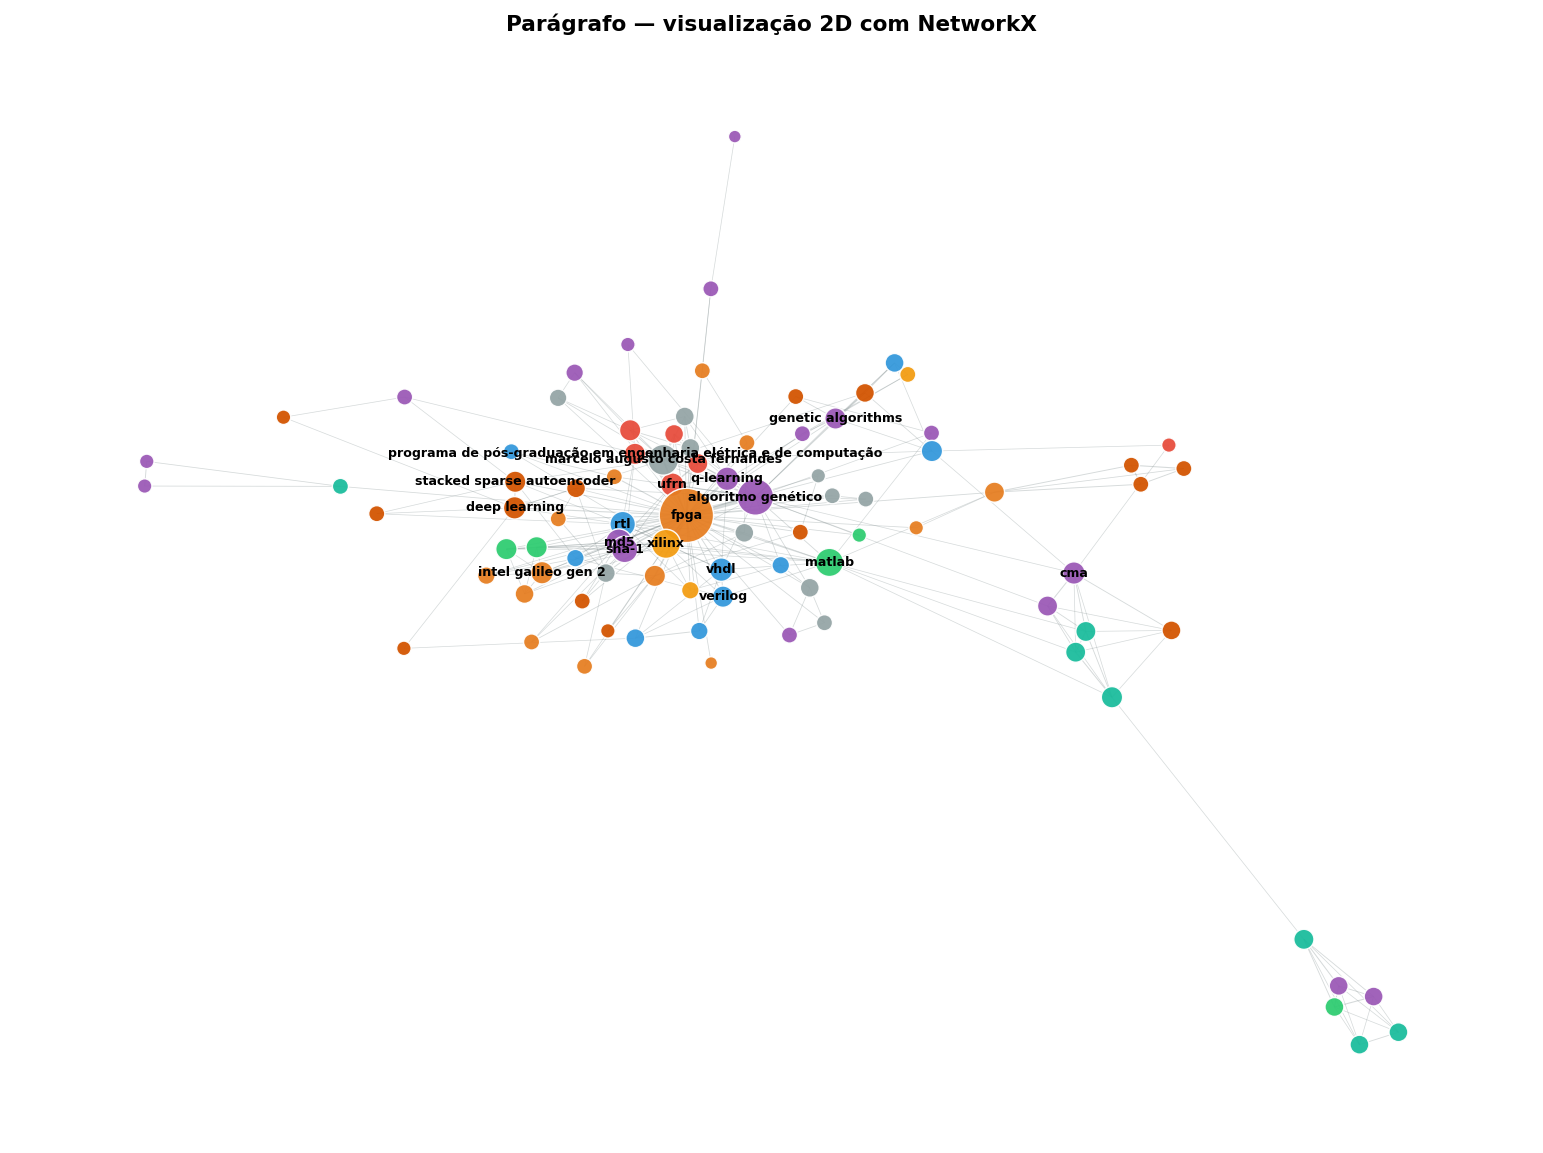

PNG salvo: ../figures/03_graph_analysis/03_paragrafo_networkx_2d.png


HTML interativo salvo: ../figures/03_graph_analysis/03_sentenca_plotly_3d.html


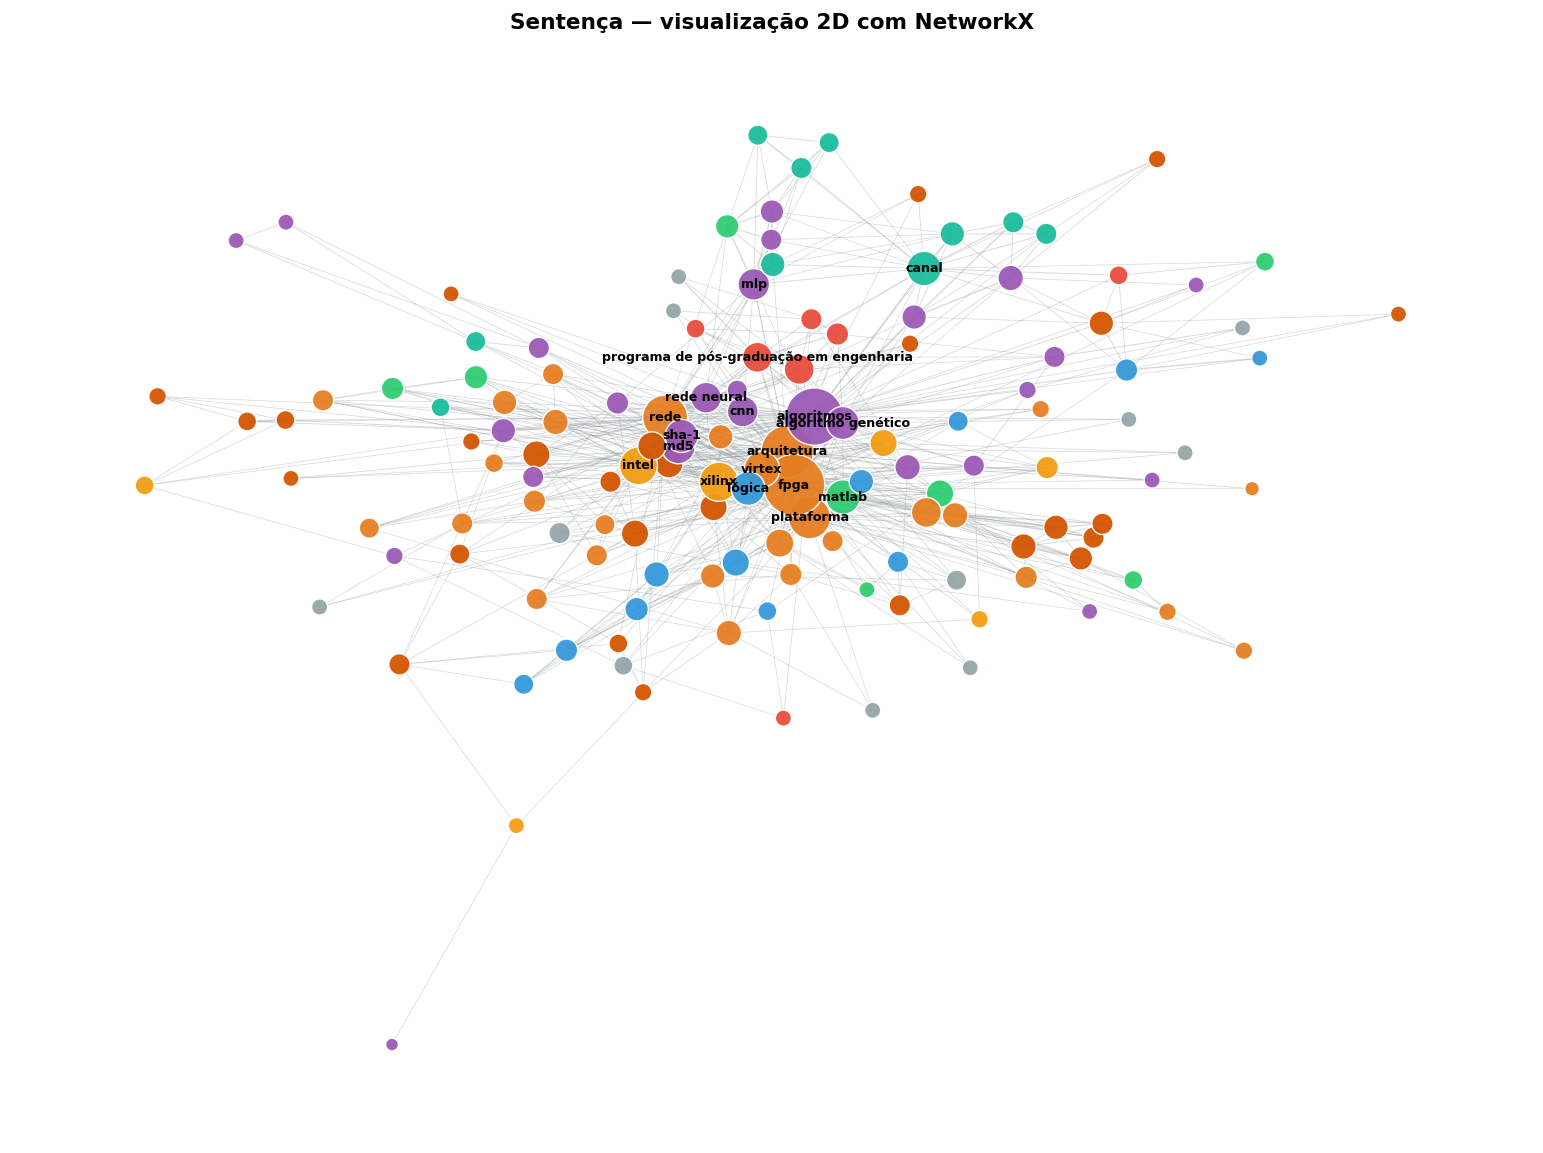

PNG salvo: ../figures/03_graph_analysis/03_sentenca_networkx_2d.png


HTML interativo salvo: ../figures/03_graph_analysis/03_k_chars_plotly_3d.html


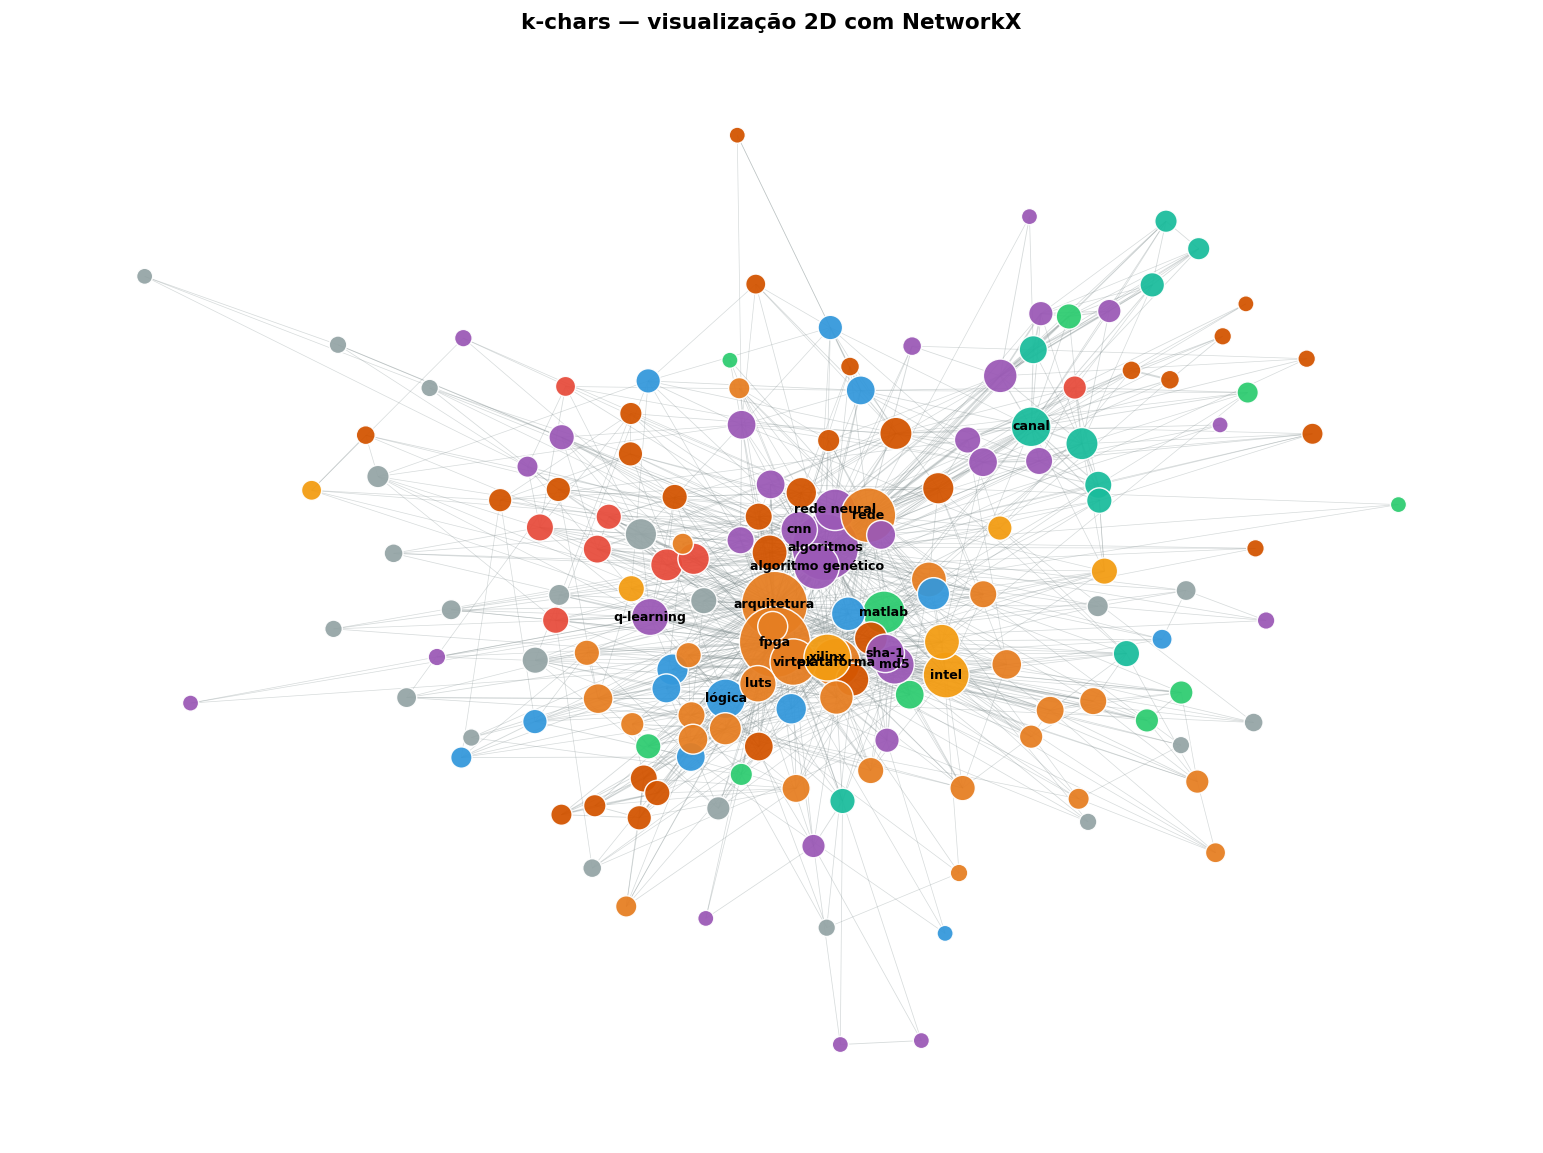

PNG salvo: ../figures/03_graph_analysis/03_k_chars_networkx_2d.png


In [22]:
# ── Cores por tipo semântico (reutilizadas do NB02) ─────────────────────────
LABEL_COLORS_VIZ = {
    "LANG":        "#3498db",
    "FRAMEWORK":   "#2ecc71",
    "HARDWARE":    "#e67e22",
    "ALGORITMO":   "#9b59b6",
    "PROTOCOLO":   "#1abc9c",
    "INSTITUICAO": "#e74c3c",
    "EMPRESA":     "#f39c12",
    "AUTOR":       "#95a5a6",
    "METODO":      "#d35400",
}

def build_visual_subgraph(G: nx.Graph, min_deg: int = 3):
    """Seleciona o GCC e filtra nós com grau mínimo para visualização."""
    if G.number_of_nodes() == 0:
        return None
    gcc_nodes = max(nx.connected_components(G), key=len)
    gcc = G.subgraph(gcc_nodes).copy()
    sub_nodes = [n for n, d in gcc.degree() if d >= min_deg]
    subg = gcc.subgraph(sub_nodes).copy()
    return subg if subg.number_of_nodes() else None

def render_graph_plotly_3d(subG: nx.Graph, nome: str, fig_name: str):
    """Renderiza um grafo 3D interativo separado com Plotly."""
    pos = nx.spring_layout(subG, dim=3, seed=42, k=1.2 / (subG.number_of_nodes() ** (1/3) + 1))
    deg_dict = dict(subG.degree())

    edge_x, edge_y, edge_z = [], [], []
    for u, v in subG.edges():
        x0, y0, z0 = pos[u]
        x1, y1, z1 = pos[v]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]
        edge_z += [z0, z1, None]

    edge_trace = go.Scatter3d(
        x=edge_x, y=edge_y, z=edge_z,
        mode="lines",
        line=dict(width=1, color="rgba(120,120,120,0.35)"),
        hoverinfo="none"
    )

    node_x, node_y, node_z, node_size, node_color, hover_text, text_labels = [], [], [], [], [], [], []
    top_labels = set(sorted(deg_dict, key=deg_dict.get, reverse=True)[:12])
    for node in subG.nodes():
        x, y, z = pos[node]
        label = subG.nodes[node].get("label", "?")
        degree = deg_dict[node]
        node_x.append(x)
        node_y.append(y)
        node_z.append(z)
        node_size.append(6 + min(16, np.sqrt(degree) * 2.8))
        node_color.append(LABEL_COLORS_VIZ.get(label, "#aaaaaa"))
        hover_text.append(f"{node}<br>tipo={label}<br>grau={degree}")
        text_labels.append(node if node in top_labels else "")

    node_trace = go.Scatter3d(
        x=node_x, y=node_y, z=node_z,
        mode="markers+text",
        text=text_labels,
        textposition="top center",
        hovertext=hover_text,
        hoverinfo="text",
        marker=dict(size=node_size, color=node_color, opacity=0.92, line=dict(width=0.8, color="white"))
    )

    fig = go.Figure(data=[edge_trace, node_trace])
    fig.update_layout(
        title=f"{nome} — GCC 3D (grau ≥ 3)",
        title_x=0.5,
        showlegend=False,
        margin=dict(l=0, r=0, t=50, b=0),
        height=760,
        scene=dict(
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            zaxis=dict(visible=False),
            bgcolor="white",
        ),
    )

    html = fig.to_html(full_html=False, include_plotlyjs="cdn", config={"responsive": True, "displaylogo": False})
    out_path = DIR_FIGURES / fig_name
    out_path.write_text(html, encoding="utf-8")
    display(HTML(html))
    print(f"HTML interativo salvo: {out_path}")

def render_graph_networkx_2d(subG: nx.Graph, nome: str, fig_name: str):
    """Renderiza uma versão 2D em NetworkX para inspecionar arestas e vizinhanças."""
    pos = nx.spring_layout(subG, seed=42, k=1.15 / (subG.number_of_nodes() ** 0.5 + 1))
    deg_dict = dict(subG.degree())
    edge_weights = [subG[u][v].get("weight", 1) for u, v in subG.edges()]
    max_w = max(edge_weights) if edge_weights else 1

    fig, ax = plt.subplots(figsize=(12, 9))
    nx.draw_networkx_edges(
        subG, pos, ax=ax,
        edge_color="#7f8c8d", alpha=0.32,
        width=[0.35 + 1.8 * w / max_w for w in edge_weights]
    )
    nx.draw_networkx_nodes(
        subG, pos, ax=ax,
        node_size=[35 + deg_dict[n] * 15 for n in subG.nodes()],
        node_color=[LABEL_COLORS_VIZ.get(subG.nodes[n].get("label", "?"), "#aaaaaa") for n in subG.nodes()],
        edgecolors="white", linewidths=0.8, alpha=0.94
    )

    top_labels = sorted(deg_dict, key=deg_dict.get, reverse=True)[:18]
    nx.draw_networkx_labels(
        subG, pos, labels={n: n for n in top_labels}, ax=ax,
        font_size=7, font_weight="bold"
    )

    ax.set_title(f"{nome} — visualização 2D com NetworkX", fontweight="bold")
    ax.axis("off")
    fig.tight_layout()
    out_path = DIR_FIGURES / fig_name
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"PNG salvo: {out_path}")

for nome, G in grafos.items():
    subG = build_visual_subgraph(G, min_deg=3)
    if subG is None:
        print(f"{nome}: sem nós com grau ≥ 3.")
        continue
    slug = nome.lower().replace("ç", "c").replace("á", "a").replace(" ", "_").replace("-", "_")
    render_graph_plotly_3d(subG, nome, f"03_{slug}_plotly_3d.html")
    render_graph_networkx_2d(subG, nome, f"03_{slug}_networkx_2d.png")

<h2 style="font-family:Georgia,serif;color:#2c3e50;border-bottom:1px solid #dce0e4;padding-bottom:6px;margin-top:30px;">
  10. Ego-Network do Hub Principal
</h2>
<p style="font-family:sans-serif;font-size:0.9em;color:#555;line-height:1.65;max-width:820px;">
  Uma <strong>ego-network</strong> é um subgrafo composto por um nó central (<em>ego</em>)
  e todos os seus vizinhos diretos. É útil para entender o contexto local do hub mais
  importante da rede. Aqui cada ego-network é exibida separadamente em 3D com <code>plotly</code>.
</p>

In [23]:
# ── Ego-networks dos hubs principais ─────────────────────────────────────────
def render_ego_plotly_3d(G: nx.Graph, nome: str, fig_name: str):
    """Renderiza em 3D a ego-network do hub principal com Plotly."""
    hub = max(G.degree(), key=lambda x: x[1])[0]
    ego = nx.ego_graph(G, hub, radius=1)
    cor = CORES_ESTRATEGIA.get(nome, COR_AZUL)
    pos = nx.spring_layout(ego, dim=3, seed=42, k=1.6)
    deg_ego = dict(ego.degree())

    edge_x, edge_y, edge_z = [], [], []
    for u, v in ego.edges():
        x0, y0, z0 = pos[u]
        x1, y1, z1 = pos[v]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]
        edge_z += [z0, z1, None]

    edge_trace = go.Scatter3d(
        x=edge_x, y=edge_y, z=edge_z,
        mode="lines",
        line=dict(width=1.2, color="rgba(90,90,90,0.32)"),
        hoverinfo="none"
    )

    xs, ys, zs, sizes, colors, hover_text = [], [], [], [], [], []
    for n in ego.nodes():
        x, y, z = pos[n]
        xs.append(x)
        ys.append(y)
        zs.append(z)
        sizes.append(18 if n == hub else 6 + min(14, np.sqrt(deg_ego[n]) * 2.6))
        colors.append(COR_VERMELHO if n == hub else cor)
        hover_text.append(f"{n}<br>grau={deg_ego[n]}")

    node_trace = go.Scatter3d(
        x=xs, y=ys, z=zs,
        mode="markers+text",
        text=list(ego.nodes()),
        textposition="top center",
        hovertext=hover_text,
        hoverinfo="text",
        marker=dict(size=sizes, color=colors, opacity=0.95, line=dict(width=0.8, color="white"))
    )

    fig = go.Figure(data=[edge_trace, node_trace])
    fig.update_layout(
        title=f"{nome} — Ego-network 3D<br>Ego: {hub} | {ego.number_of_nodes()-1} vizinhos",
        title_x=0.5,
        showlegend=False,
        margin=dict(l=0, r=0, t=60, b=0),
        height=760,
        scene=dict(
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            zaxis=dict(visible=False),
            bgcolor="white",
        ),
    )

    html = fig.to_html(full_html=False, include_plotlyjs="cdn", config={"responsive": True, "displaylogo": False})
    out_path = DIR_FIGURES / fig_name
    out_path.write_text(html, encoding="utf-8")
    display(HTML(html))
    print(f"HTML interativo salvo: {out_path}")

for nome, G in grafos.items():
    slug = nome.lower().replace("ç", "c").replace("á", "a").replace(" ", "_").replace("-", "_")
    render_ego_plotly_3d(G, nome, f"03_ego_{slug}_plotly_3d.html")

HTML interativo salvo: ../figures/03_graph_analysis/03_ego_paragrafo_plotly_3d.html


HTML interativo salvo: ../figures/03_graph_analysis/03_ego_sentenca_plotly_3d.html


HTML interativo salvo: ../figures/03_graph_analysis/03_ego_k_chars_plotly_3d.html


<h2 style="font-family:Georgia,serif;color:#2c3e50;border-bottom:1px solid #dce0e4;padding-bottom:6px;margin-top:30px;">
  11. Verificação de Propriedades Small World
</h2>
<p style="font-family:sans-serif;font-size:0.9em;color:#555;line-height:1.65;max-width:820px;">
  Uma rede <strong>small world</strong> apresenta simultaneamente:
  <br>&emsp;• alto clustering em relação a uma rede aleatória equivalente (C<sub>real</sub> &gg; C<sub>rand</sub>)
  <br>&emsp;• distância média próxima à de uma rede aleatória (L<sub>real</sub> &asymp; L<sub>rand</sub>)
  <br><br>
  Comparamos cada grafo com um grafo aleatório de Erdős–Rényi com os mesmos N e E.
  Os índices &sigma; e &omega; são medidas quantitativas de small-worldness.
</p>

In [24]:
# ── Teste de small world — comparação com Erdős–Rényi ───────────────────────
sw_rows = []

for nome, G in grafos.items():
    gcc_nodes = max(nx.connected_components(G), key=len)
    GCC = G.subgraph(gcc_nodes).copy()
    n = GCC.number_of_nodes()
    m = GCC.number_of_edges()
    p = (2 * m) / (n * (n - 1)) if n > 1 else 0

    # Grafo aleatório equivalente
    G_rand = nx.erdos_renyi_graph(n, p, seed=42)
    gcc_rand = max(nx.connected_components(G_rand), key=len) if nx.number_connected_components(G_rand) > 0 else set(G_rand.nodes())
    GCC_rand = G_rand.subgraph(gcc_rand).copy()

    C_real = nx.average_clustering(GCC)
    C_rand = nx.average_clustering(GCC_rand)

    try:
        L_real = nx.average_shortest_path_length(GCC)
    except Exception:
        L_real = float("nan")
    try:
        L_rand = nx.average_shortest_path_length(GCC_rand)
    except Exception:
        L_rand = float("nan")

    ratio_C = C_real / C_rand if C_rand > 0 else float("nan")
    ratio_L = L_real / L_rand if L_rand > 0 and not np.isnan(L_real) else float("nan")

    sw_rows.append({
        "Estratégia":         nome,
        "C real":             round(C_real, 5),
        "C aleatório":        round(C_rand, 5),
        "C_real / C_rand":    round(ratio_C, 2),
        "L real":             round(L_real, 3) if not np.isnan(L_real) else "N/A",
        "L aleatório":        round(L_rand, 3) if not np.isnan(L_rand) else "N/A",
        "L_real / L_rand":    round(ratio_L, 3) if not np.isnan(ratio_L) else "N/A",
        "Small World?":       "✓ Sim" if (ratio_C > 2 and 0.8 < ratio_L < 1.5) else "— Não conclusivo",
    })

df_sw = pd.DataFrame(sw_rows).set_index("Estratégia")
df_sw

,C real,C aleatório,C_real / C_rand,L real,L aleatório,L_real / L_rand,Small World?
Estratégia,,,,,,,
Parágrafo,0.50969,0.01114,45.76,3.171,3.603,0.880,✓ Sim
Sentença,0.53249,0.04409,12.08,2.670,2.723,0.980,✓ Sim
k-chars,0.65709,0.06754,9.73,2.373,2.381,0.996,✓ Sim


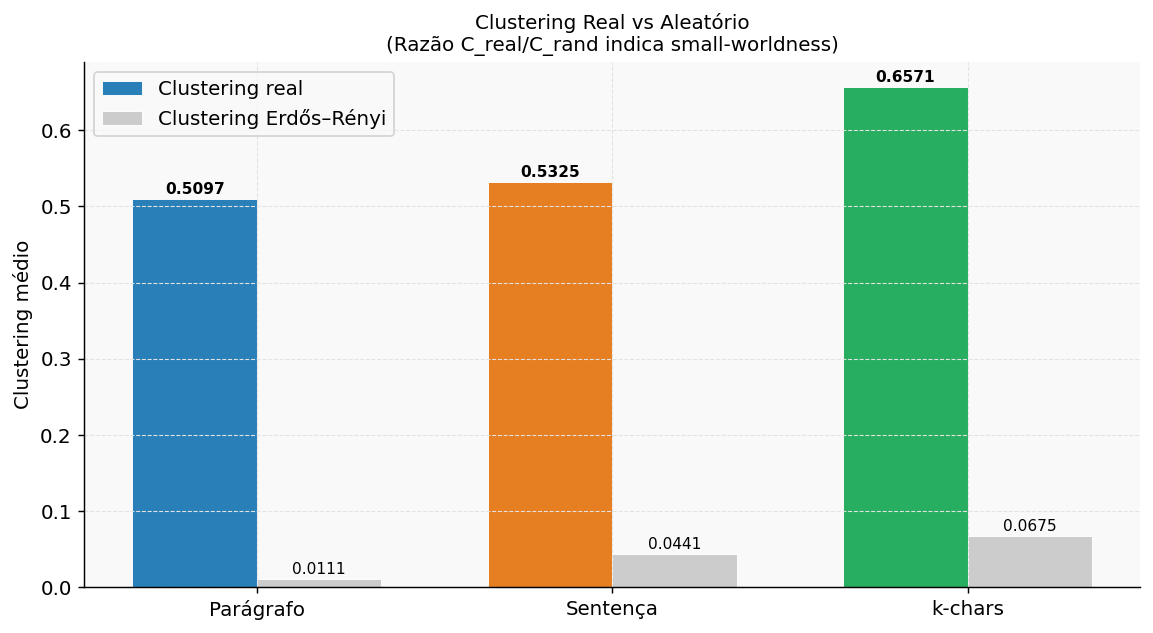

Figura salva: 03_small_world.png


In [25]:
# ── Visualização comparativa clustering real vs aleatório ────────────────────
estrategias = list(grafos.keys())
c_real_vals = df_sw["C real"].values.astype(float)
c_rand_vals = df_sw["C aleatório"].values.astype(float)

x = np.arange(len(estrategias))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, c_real_vals, width, label="Clustering real",
               color=[CORES_ESTRATEGIA.get(e, COR_AZUL) for e in estrategias],
               edgecolor="white", linewidth=0.5)
bars2 = ax.bar(x + width/2, c_rand_vals, width, label="Clustering Erdős–Rényi",
               color="#cccccc", edgecolor="white", linewidth=0.5)

for bar, val in zip(bars1, c_real_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{val:.4f}", ha="center", va="bottom", fontsize=8.5, fontweight="bold")
for bar, val in zip(bars2, c_rand_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{val:.4f}", ha="center", va="bottom", fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels(estrategias)
ax.set_ylabel("Clustering médio")
ax.set_title("Clustering Real vs Aleatório\n(Razão C_real/C_rand indica small-worldness)",
             fontsize=11)
ax.legend()
plt.tight_layout()
plt.savefig(DIR_FIGURES / "03_small_world.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salva: 03_small_world.png")

<h2 style="font-family:Georgia,serif;color:#2c3e50;border-bottom:1px solid #dce0e4;padding-bottom:6px;margin-top:30px;">
  12. Top Pares de Coocorrência (Arestas Mais Pesadas)
</h2>
<p style="font-family:sans-serif;font-size:0.9em;color:#555;line-height:1.65;max-width:820px;">
  Os pares de entidades com maior frequência de coocorrência revelam as relações mais
  consolidadas no corpus. Esta análise qualitativa permite avaliar se as relações capturadas
  fazem sentido semântico e comparar como cada estratégia prioriza diferentes tipos de associação.
</p>

In [26]:
# ── Top-20 arestas por peso em cada grafo ────────────────────────────────────
for nome, G in grafos.items():
    edges_sorted = sorted(G.edges(data=True),
                          key=lambda x: x[2].get("weight", 1), reverse=True)[:20]
    print(f"\n{'═'*70}")
    print(f"  Top 20 pares — {nome}")
    print(f"{'═'*70}")
    print(f"  {'Entidade A':30s}  {'Entidade B':30s}  Peso")
    print(f"  {'─'*30}  {'─'*30}  {'─'*4}")
    for u, v, data in edges_sorted:
        w = data.get("weight", 1)
        print(f"  {u:30s}  {v:30s}  {w:>4}")


══════════════════════════════════════════════════════════════════════
  Top 20 pares — Parágrafo
══════════════════════════════════════════════════════════════════════
  Entidade A                      Entidade B                      Peso
  ──────────────────────────────  ──────────────────────────────  ────
  fpga                            algoritmo genético                44
  md5                             sha-1                             33
  marcelo augusto costa fernandes  fpga                              16
  fpga                            md5                               14
  fpga                            sha-1                             13
  fpga                            asic                              12
  fpga                            q-learning                        12
  ufrn                            centro de tecnologia              10
  ufrn                            fpga                              10
  fpga                            xilinx        

<h2 style="font-family:Georgia,serif;color:#2c3e50;border-bottom:1px solid #dce0e4;padding-bottom:6px;margin-top:30px;">
  13. Resumo e Artefatos Gerados
</h2>
<p style="font-family:sans-serif;font-size:0.9em;color:#555;line-height:1.65;max-width:820px;">
  Síntese dos artefatos produzidos por este notebook e que serão consumidos pelo Notebook 04.
</p>

In [27]:
# ── Resumo final ─────────────────────────────────────────────────────────────
sep = "=" * 62
print(sep)
print("  RESUMO — NB03 Construção e Análise dos Grafos")
print(sep)

print("\n  GRAFOS EXPORTADOS:")
for nome, fname in nomes_arquivo.items():
    G = grafos[nome]
    path = DIR_GRAPHS / fname
    flag = "✓" if path.exists() else "✗"
    print(f"  {flag}  {fname:35s}  {G.number_of_nodes()} nós, {G.number_of_edges()} arestas")

print("\n  FIGURAS GERADAS:")
figs_esperadas = [
    "03_metrics_heatmap.png",
    "03_degree_distribution.png",
    "03_top_hubs.png",
    "03_components.png",
    "03_clustering_distribution.png",
    "03_paragrafo_plotly_3d.html",
    "03_paragrafo_networkx_2d.png",
    "03_sentenca_plotly_3d.html",
    "03_sentenca_networkx_2d.png",
    "03_k_chars_plotly_3d.html",
    "03_k_chars_networkx_2d.png",
    "03_ego_paragrafo_plotly_3d.html",
    "03_ego_sentenca_plotly_3d.html",
    "03_ego_k_chars_plotly_3d.html",
    "03_small_world.png",
]
for fig_name in figs_esperadas:
    path = DIR_FIGURES / fig_name
    flag = "✓" if path.exists() else "✗"
    print(f"  {flag}  {fig_name}")

print("\n  ARQUIVOS DE RESULTADO:")
csv_path = DIR_RESULTS / "03_metrics_summary.csv"
flag = "✓" if csv_path.exists() else "✗"
print(f"  {flag}  {csv_path.name}  →  usado pelo Notebook 04")

print()
print(sep)
print("  Próximo passo: Notebook 04 — Comparação entre Estratégias")
print(sep)

  RESUMO — NB03 Construção e Análise dos Grafos

  GRAFOS EXPORTADOS:
  ✓  graph_paragraph.graphml              161 nós, 359 arestas
  ✓  graph_sentence.graphml               179 nós, 739 arestas
  ✓  graph_kchars.graphml                 192 nós, 1184 arestas

  FIGURAS GERADAS:
  ✓  03_metrics_heatmap.png
  ✓  03_degree_distribution.png
  ✓  03_top_hubs.png
  ✓  03_components.png
  ✓  03_clustering_distribution.png
  ✓  03_paragrafo_plotly_3d.html
  ✓  03_paragrafo_networkx_2d.png
  ✓  03_sentenca_plotly_3d.html
  ✓  03_sentenca_networkx_2d.png
  ✓  03_k_chars_plotly_3d.html
  ✓  03_k_chars_networkx_2d.png
  ✓  03_ego_paragrafo_plotly_3d.html
  ✓  03_ego_sentenca_plotly_3d.html
  ✓  03_ego_k_chars_plotly_3d.html
  ✓  03_small_world.png

  ARQUIVOS DE RESULTADO:
  ✓  03_metrics_summary.csv  →  usado pelo Notebook 04

  Próximo passo: Notebook 04 — Comparação entre Estratégias
